# Smart Nutrition Tracker - Deep Learning Model

Notebook ini membangun sistem analisis gizi anak usia 0-6 tahun (golden age) menggunakan Deep Learning dengan TensorFlow Functional API.

## Deskripsi Proyek

Model ini dirancang untuk:
- Memprediksi skor gizi makanan berdasarkan komposisi nutrisi (regresi)
- Mengklasifikasikan status nutrisi makanan untuk anak usia dini
- Memberikan rekomendasi makanan lokal berdasarkan pemenuhan AKG (Angka Kecukupan Gizi)

## Dataset

| Dataset | Sumber | Isi |
|---|---|---|
| `panganku_dataset.csv` | Web scraping panganku.org (TKPI 2017 Kemenkes RI) | 1.146 bahan makanan, 28 kolom nutrisi |
| `akg_anak.csv` | Permenkes RI No. 28 Tahun 2019 | AKG harian 4 kelompok umur anak |
| `final_dataset.csv` | Hasil data cleaning + feature engineering | Dataset siap pakai untuk modeling |

## Arsitektur Model

- **TensorFlow Functional API** dengan multi-output
- **Custom Layer**: `NutritionNormalizationLayer` untuk normalisasi per-nutrisi adaptif
- **Custom Loss Function**: `WeightedNutritionLoss` yang memberi bobot lebih pada nutrisi kritis
- **Custom Callback**: `NutritionMetricsCallback` untuk monitoring performa gizi selama training
- **Output**: Prediksi skor gizi (regresi) + klasifikasi status energi

---
## 1. Import Library dan Konfigurasi

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

2026-05-14 06:14:27.173814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778739267.428225      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778739267.503342      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778739268.109886      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778739268.109951      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778739268.109955      16 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.3.3


---
## 2. Load dan Eksplorasi Dataset

In [2]:
# Load ketiga dataset
df_panganku = pd.read_csv('/kaggle/input/datasets/yuyunnailufar/capstone/panganku_dataset.csv')
df_akg      = pd.read_csv('/kaggle/input/datasets/yuyunnailufar/capstone/akg_anak.csv')
df          = pd.read_csv('/kaggle/input/datasets/yuyunnailufar/capstone/final_dataset.csv')

print(f"panganku_dataset : {df_panganku.shape}")
print(f"akg_anak         : {df_akg.shape}")
print(f"final_dataset    : {df.shape}")
print()
print("AKG Anak Usia 0-6 Tahun (Permenkes RI No. 28 Tahun 2019)")
print("-" * 60)
print(df_akg.to_string(index=False))

panganku_dataset : (1146, 28)
akg_anak         : (4, 18)
final_dataset    : (1146, 33)

AKG Anak Usia 0-6 Tahun (Permenkes RI No. 28 Tahun 2019)
------------------------------------------------------------
kelompok_umur  energi_kal  protein_g  lemak_g  karbohidrat_g  serat_g  air_ml  kalsium_mg  fosfor_mg  besi_mg  natrium_mg  kalium_mg  seng_mg  retinol_mcg  thiamin_mg  riboflavin_mg  niasin_mg  vit_c_mg
    0-5 bulan         550         12       34             58        0     700         200        100      0.3         120        400        2          375         0.3            0.3          3        40
   6-11 bulan         800         18       35             82       11     900         270        275     11.0         370        700        3          400         0.4            0.4          5        50
    1-3 tahun        1350         20       45            215       19    1150         650        500      7.0         800       2000        4          400         0.6            0.7    

In [3]:
FITUR_NUTRISI = [
    'energi_kal', 'protein_g', 'lemak_g', 'karbo_g',
    'serat_g',    'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'kalium_mg',  'seng_mg',  'retinol_mcg',
    'thiamin_mg', 'riboflavin_mg', 'niasin_mg', 'vit_c_mg'
]

print("Statistik Deskriptif Fitur Nutrisi")
print("-" * 40)
print(df[FITUR_NUTRISI].describe().round(2).to_string())
print()
print(f"Distribusi skor_gizi_anak:")
print(df['skor_gizi_anak'].describe().round(4))

Statistik Deskriptif Fitur Nutrisi
----------------------------------------
       energi_kal  protein_g  lemak_g  karbo_g  serat_g  kalsium_mg  fosfor_mg  besi_mg  natrium_mg  kalium_mg  seng_mg  retinol_mcg  thiamin_mg  riboflavin_mg  niasin_mg  vit_c_mg
count     1146.00    1146.00  1146.00  1146.00  1146.00     1146.00    1146.00  1146.00     1146.00    1146.00  1146.00      1146.00     1146.00        1146.00    1146.00   1146.00
mean       198.45       9.67     7.38    23.76     2.49      106.39     144.28     3.32       93.85     227.42     1.20        26.58        0.38           0.18       1.63      8.69
std        162.39      11.50    13.70    25.00     4.12      147.15     153.82     5.68      169.09     177.67     2.74       109.33        5.91           0.90       4.75     23.17
min          8.00       0.00     0.00     0.00     0.00        0.00       0.00     0.00        0.00       0.00     0.00         0.00        0.00           0.00       0.00      0.00
25%         74.00  

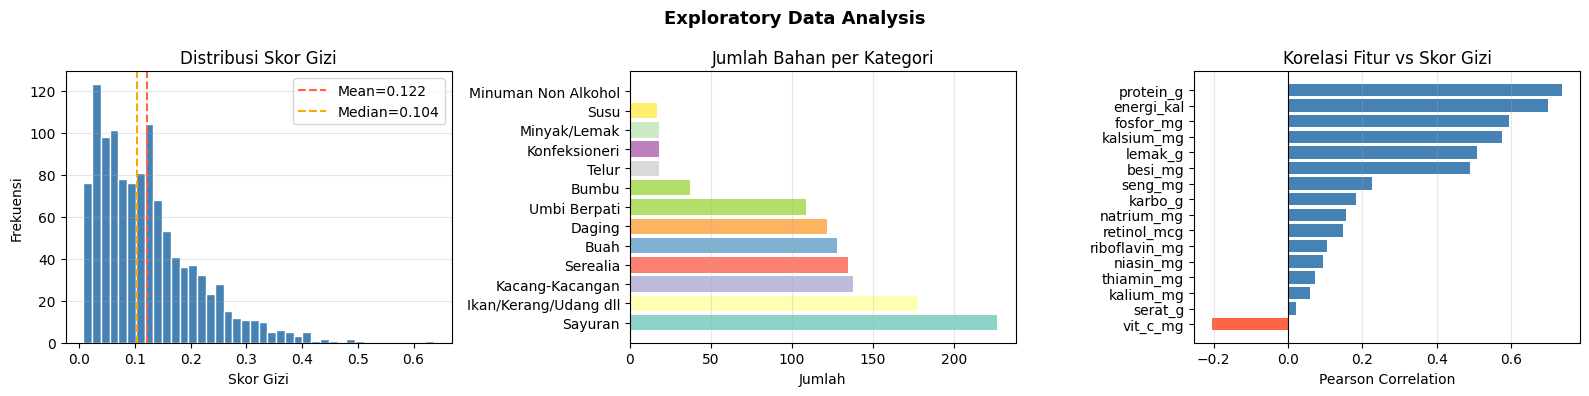

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold')

# Distribusi skor gizi
axes[0].hist(df['skor_gizi_anak'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['skor_gizi_anak'].mean(),   color='tomato',  linestyle='--', label=f"Mean={df['skor_gizi_anak'].mean():.3f}")
axes[0].axvline(df['skor_gizi_anak'].median(), color='orange',  linestyle='--', label=f"Median={df['skor_gizi_anak'].median():.3f}")
axes[0].set_title('Distribusi Skor Gizi')
axes[0].set_xlabel('Skor Gizi')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Distribusi kategori makanan
kat_count = df['kategori'].value_counts()
axes[1].barh(kat_count.index, kat_count.values, color=plt.cm.Set3(np.linspace(0, 1, len(kat_count))))
axes[1].set_title('Jumlah Bahan per Kategori')
axes[1].set_xlabel('Jumlah')
axes[1].grid(axis='x', alpha=0.3)

# Korelasi fitur utama dengan skor gizi
corr_vals = df[FITUR_NUTRISI + ['skor_gizi_anak']].corr()['skor_gizi_anak'].drop('skor_gizi_anak').sort_values()
colors_corr = ['tomato' if v < 0 else 'steelblue' for v in corr_vals]
axes[2].barh(corr_vals.index, corr_vals.values, color=colors_corr)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Korelasi Fitur vs Skor Gizi')
axes[2].set_xlabel('Pearson Correlation')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_01_eda.png', dpi=120, bbox_inches='tight')
plt.show()

Cell 4 — Feature Engineering: Buat Target Klasifikasi Multi-Kelas

In [5]:
# Buat target klasifikasi 4 kelas berdasarkan quartile skor gizi
# Ini lebih masuk akal daripada prediksi skor agregat (yang terbukti gagal)
# karena kelas berdasarkan percentile memberi distribusi yang seimbang

q25, q50, q75 = df['skor_gizi_anak'].quantile([0.25, 0.50, 0.75])

def buat_kelas_gizi(skor):
    if skor <= q25:
        return 0   # Rendah
    elif skor <= q50:
        return 1   # Cukup
    elif skor <= q75:
        return 2   # Baik
    else:
        return 3   # Sangat Baik

LABEL_KELAS = {0: 'Rendah', 1: 'Cukup', 2: 'Baik', 3: 'Sangat Baik'}

df['kelas_gizi'] = df['skor_gizi_anak'].apply(buat_kelas_gizi)

print("Quartile Skor Gizi:")
print(f"  Q25 = {q25:.4f}  |  Q50 = {q50:.4f}  |  Q75 = {q75:.4f}")
print()
print("Distribusi Kelas Target:")
for kls, nama in LABEL_KELAS.items():
    n = (df['kelas_gizi'] == kls).sum()
    print(f"  Kelas {kls} ({nama:<12}): {n:>4} sampel ({n/len(df)*100:.1f}%)")

Quartile Skor Gizi:
  Q25 = 0.0514  |  Q50 = 0.1044  |  Q75 = 0.1647

Distribusi Kelas Target:
  Kelas 0 (Rendah      ):  287 sampel (25.0%)
  Kelas 1 (Cukup       ):  286 sampel (25.0%)
  Kelas 2 (Baik        ):  287 sampel (25.0%)
  Kelas 3 (Sangat Baik ):  286 sampel (25.0%)


In [6]:
X = df[FITUR_NUTRISI].values.astype(np.float32)
y = df['kelas_gizi'].values.astype(np.int32)

# Split dulu sebelum SMOTE — SMOTE hanya boleh diterapkan pada train set
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train_raw, y_train_raw, test_size=0.176, random_state=42, stratify=y_train_raw
)

print(f"Sebelum SMOTE:")
print(f"  Train  : {len(X_train_raw):>4} sampel")
print(f"  Val    : {len(X_val):>4} sampel")
print(f"  Test   : {len(X_test):>4} sampel")

# Standardisasi — fit hanya pada train
scaler = StandardScaler()
X_train_raw_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val_sc       = scaler.transform(X_val).astype(np.float32)
X_test_sc      = scaler.transform(X_test).astype(np.float32)

# SMOTE pada train set yang sudah di-scale
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sc, y_train = smote.fit_resample(X_train_raw_sc, y_train_raw)
X_train_sc = X_train_sc.astype(np.float32)
y_train    = y_train.astype(np.int32)

print()
print(f"Setelah SMOTE:")
print(f"  Train  : {len(X_train_sc):>4} sampel")
print(f"  Distribusi kelas setelah SMOTE:")
for kls, nama in LABEL_KELAS.items():
    n = (y_train == kls).sum()
    print(f"    Kelas {kls} ({nama:<12}): {n}")

# One-hot encoding untuk categorical crossentropy
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=4)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=4)

print()
print(f"Shape X_train_sc  : {X_train_sc.shape}")
print(f"Shape y_train_oh  : {y_train_oh.shape}")

Sebelum SMOTE:
  Train  :  802 sampel
  Val    :  172 sampel
  Test   :  172 sampel

Setelah SMOTE:
  Train  :  804 sampel
  Distribusi kelas setelah SMOTE:
    Kelas 0 (Rendah      ): 201
    Kelas 1 (Cukup       ): 201
    Kelas 2 (Baik        ): 201
    Kelas 3 (Sangat Baik ): 201

Shape X_train_sc  : (804, 16)
Shape y_train_oh  : (804, 4)


In [7]:
class NutritionAttentionLayer(layers.Layer):
    """
    Custom Layer: Feature Attention untuk Fitur Nutrisi.

    Belajar memberi bobot berbeda tiap fitur nutrisi secara adaptif.
    Nutrisi yang lebih relevan untuk klasifikasi kelas gizi akan
    mendapat attention weight lebih tinggi.

    Mekanisme:
        1. Linear projection ke ruang hidden (tanh activation)
        2. Projeksi kembali ke n_features (sigmoid) -> attention weights [0,1]
        3. Hadamard product: fitur * attention_weights
        4. Residual + LayerNorm untuk stabilitas
    """

    def __init__(self, hidden_units=32, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        n = input_shape[-1]
        self.W1 = self.add_weight(name='W1', shape=(n, self.hidden_units),
                                  initializer='glorot_uniform', trainable=True)
        self.b1 = self.add_weight(name='b1', shape=(self.hidden_units,),
                                  initializer='zeros', trainable=True)
        self.W2 = self.add_weight(name='W2', shape=(self.hidden_units, n),
                                  initializer='glorot_uniform', trainable=True)
        self.layer_norm = layers.LayerNormalization()
        self.dropout    = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        h       = tf.nn.tanh(tf.matmul(inputs, self.W1) + self.b1)
        weights = tf.nn.sigmoid(tf.matmul(h, self.W2))
        weights = self.dropout(weights, training=training)
        out     = self.layer_norm(inputs + inputs * weights)
        return out, weights

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'hidden_units': self.hidden_units, 'dropout_rate': self.dropout_rate})
        return cfg


# Verifikasi
_x    = tf.random.normal((4, len(FITUR_NUTRISI)))
_attn = NutritionAttentionLayer(hidden_units=32, name='verify')
_out, _w = _attn(_x)
print(f"NutritionAttentionLayer OK")
print(f"  Input  : {_x.shape}")
print(f"  Output : {_out.shape}")
print(f"  Weights: {_w.shape}")

NutritionAttentionLayer OK
  Input  : (4, 16)
  Output : (4, 16)
  Weights: (4, 16)


2026-05-14 06:14:58.729815: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
class FocalLoss(keras.losses.Loss):
    """
    Custom Loss Function: Focal Loss untuk Klasifikasi Multi-Kelas.

    Focal Loss memberi penalti lebih besar pada sampel yang sulit
    diprediksi (hard examples) dan mengurangi kontribusi sampel mudah.
    Ini lebih efektif dari crossentropy biasa untuk masalah dengan
    distribusi kelas yang tidak merata.

    Formula:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameter:
        gamma : Focusing parameter. Semakin besar, semakin fokus
                pada hard examples. Nilai umum: 1.0 - 3.0
        alpha : Bobot per kelas (list). None = bobot sama rata.
    """

    def __init__(self, gamma=2.0, alpha=None, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_loss = -y_true * tf.math.log(y_pred)

        p_t         = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        loss = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_t = tf.constant(self.alpha, dtype=tf.float32)
            loss    = loss * alpha_t

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


# Verifikasi
_fl   = FocalLoss(gamma=2.0)
_yt   = tf.constant([[1,0,0,0],[0,0,1,0]], dtype=tf.float32)
_yp   = tf.constant([[0.8,0.1,0.05,0.05],[0.1,0.2,0.6,0.1]], dtype=tf.float32)
print(f"FocalLoss OK")
print(f"  Loss value: {_fl(_yt, _yp).numpy():.6f}")

FocalLoss OK
  Loss value: 0.045329


In [9]:
class EarlyStoppingWithReport(keras.callbacks.Callback):
    """
    Custom Callback: Early Stopping dengan laporan domain gizi.

    Menggabungkan early stopping standar dengan monitoring metrik
    yang relevan secara domain: per-kelas accuracy pada data validasi.

    Parameter:
        X_val        : Fitur validasi
        y_val_int    : Label validasi (integer, bukan one-hot)
        patience     : Jumlah epoch toleransi tanpa improvement
        min_delta    : Improvement minimum yang dianggap signifikan
        label_map    : Dict {int: str} nama kelas
    """

    def __init__(self, X_val, y_val_int, patience=15, min_delta=1e-4, label_map=None):
        super().__init__()
        self.X_val       = X_val
        self.y_val_int   = y_val_int
        self.patience    = patience
        self.min_delta   = min_delta
        self.label_map   = label_map or {}
        self.best_loss   = np.inf
        self.wait        = 0
        self.best_epoch  = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss', np.inf)

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.wait         = 0
            self.best_epoch   = epoch + 1
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1

        # Cetak laporan per-kelas setiap 10 epoch
        if (epoch + 1) % 10 == 0:
            y_pred_prob = self.model.predict(self.X_val, verbose=0)
            y_pred      = np.argmax(y_pred_prob, axis=1)
            per_kelas   = []
            for kls in sorted(self.label_map.keys()):
                mask  = self.y_val_int == kls
                if mask.sum() > 0:
                    acc_k = (y_pred[mask] == kls).mean() * 100
                    per_kelas.append(f"{self.label_map[kls]}={acc_k:.0f}%")
            info = " | ".join(per_kelas)
            print(f"  [Epoch {epoch+1:3d}] val_loss={val_loss:.5f} | {info} | wait={self.wait}/{self.patience}")

        # Stop jika tidak ada improvement
        if self.wait >= self.patience:
            self.model.set_weights(self.best_weights)
            self.model.stop_training = True
            print(f"\n  Early stopping. Best epoch: {self.best_epoch}, best val_loss: {self.best_loss:.5f}")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
        print()
        print("=" * 50)
        print(f"Training selesai. Best epoch: {self.best_epoch}")
        print(f"Best val_loss             : {self.best_loss:.5f}")
        print("=" * 50)


print("EarlyStoppingWithReport OK")

EarlyStoppingWithReport OK


In [10]:
def build_model(n_features, n_classes=4, dropout_rate=0.3):
    """
    Model klasifikasi gizi anak dengan TensorFlow Functional API.

    Arsitektur:
        Input
          -> NutritionAttentionLayer   (custom, belajar feature importance)
          -> Dense(128) + BN + Dropout
          -> Dense(128) + BN           + Residual Connection
          -> Dense(64)  + BN + Dropout
          -> Dense(32)  + Dropout
          -> Output Dense(4, softmax)

    Parameter:
        n_features   : Jumlah fitur input
        n_classes    : Jumlah kelas output (default: 4)
        dropout_rate : Dropout rate backbone
    """
    inputs = keras.Input(shape=(n_features,), name='nutrisi_input')

    # Custom attention layer
    x, _ = NutritionAttentionLayer(hidden_units=32, dropout_rate=0.1,
                                    name='nutrition_attention')(inputs)

    # Block 1
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4),
                      name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout_rate, name='drop_1')(x)

    # Block 2 + Residual
    h = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4),
                      name='dense_2')(x)
    h = layers.BatchNormalization(name='bn_2')(h)
    h = layers.Activation('relu', name='relu_2')(h)
    x = layers.Add(name='residual')([x, h])
    x = layers.Dropout(dropout_rate, name='drop_2')(x)

    # Block 3
    x = layers.Dense(64, activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop_3')(x)

    # Block 4
    x = layers.Dense(32, activation='relu', name='dense_4')(x)
    x = layers.Dropout(0.1, name='drop_4')(x)

    # Output
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='SmartNutritionTracker')
    return model


model = build_model(n_features=len(FITUR_NUTRISI), n_classes=4, dropout_rate=0.3)
model.summary()

Model: "SmartNutritionTracker"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nutrisi_input       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nutrition_attention │ [(None, 16),      │      1,088 │ nutrisi_input[0]… │
│ (NutritionAttentio… │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,176 │ nutrition_attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 128)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 128)       │          0 │ drop_1[0][0],     │
│                     │                   │            │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 128)       │          0 │ residual[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 64)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        132 │ drop_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,524 (123.14 KB)

 Trainable params: 30,884 (120.64 KB)

 Non-trainable params: 640 (2.50 KB)

In [11]:
focal_loss = FocalLoss(gamma=2.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss,
    metrics=['accuracy', keras.metrics.AUC(name='auc', multi_label=False)]
)

custom_es = EarlyStoppingWithReport(
    X_val      = X_val_sc,
    y_val_int  = y_val,
    patience   = 20,
    min_delta  = 1e-4,
    label_map  = LABEL_KELAS
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 8,
    min_lr   = 1e-6,
    verbose  = 0
)

print("Memulai training...")
print("=" * 55)

history = model.fit(
    X_train_sc,
    y_train_oh,
    validation_data = (X_val_sc, y_val_oh),
    epochs          = 200,
    batch_size      = 32,
    callbacks       = [custom_es, reduce_lr],
    verbose         = 0
)

print(f"Total epoch dijalankan: {len(history.history['loss'])}")

Memulai training...
  [Epoch  10] val_loss=0.21983 | Rendah=98% | Cukup=72% | Baik=81% | Sangat Baik=79% | wait=0/20
  [Epoch  20] val_loss=0.17416 | Rendah=95% | Cukup=74% | Baik=79% | Sangat Baik=84% | wait=1/20
  [Epoch  30] val_loss=0.16283 | Rendah=98% | Cukup=74% | Baik=70% | Sangat Baik=86% | wait=0/20
  [Epoch  40] val_loss=0.16319 | Rendah=98% | Cukup=74% | Baik=74% | Sangat Baik=88% | wait=8/20
  [Epoch  50] val_loss=0.16193 | Rendah=98% | Cukup=74% | Baik=72% | Sangat Baik=88% | wait=18/20

  Early stopping. Best epoch: 32, best val_loss: 0.15810

Training selesai. Best epoch: 32
Best val_loss             : 0.15810
Total epoch dijalankan: 52


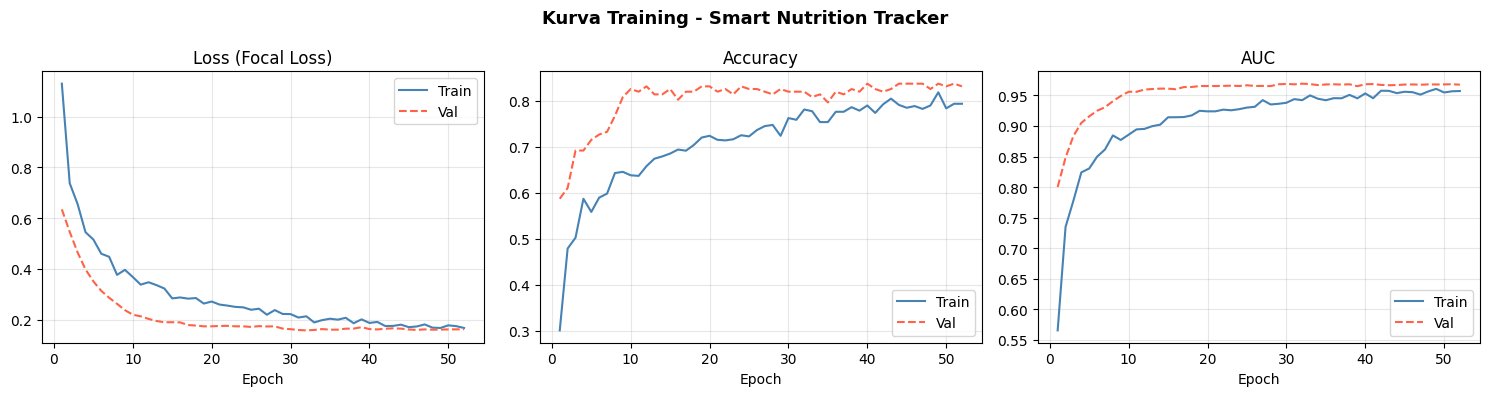

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Kurva Training - Smart Nutrition Tracker', fontsize=13, fontweight='bold')

ep = range(1, len(history.history['loss']) + 1)

axes[0].plot(ep, history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(ep, history.history['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[0].set_title('Loss (Focal Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(ep, history.history['val_accuracy'], label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history.history['auc'],     label='Train', color='steelblue')
axes[2].plot(ep, history.history['val_auc'], label='Val',   color='tomato', linestyle='--')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot_02_training.png', dpi=120, bbox_inches='tight')
plt.show()

EVALUASI MODEL - TEST SET

              precision    recall  f1-score   support

      Rendah     0.7679    1.0000    0.8687        43
       Cukup     0.9630    0.6047    0.7429        43
        Baik     0.8043    0.8605    0.8315        43
 Sangat Baik     0.9070    0.9070    0.9070        43

    accuracy                         0.8430       172
   macro avg     0.8605    0.8430    0.8375       172
weighted avg     0.8605    0.8430    0.8375       172



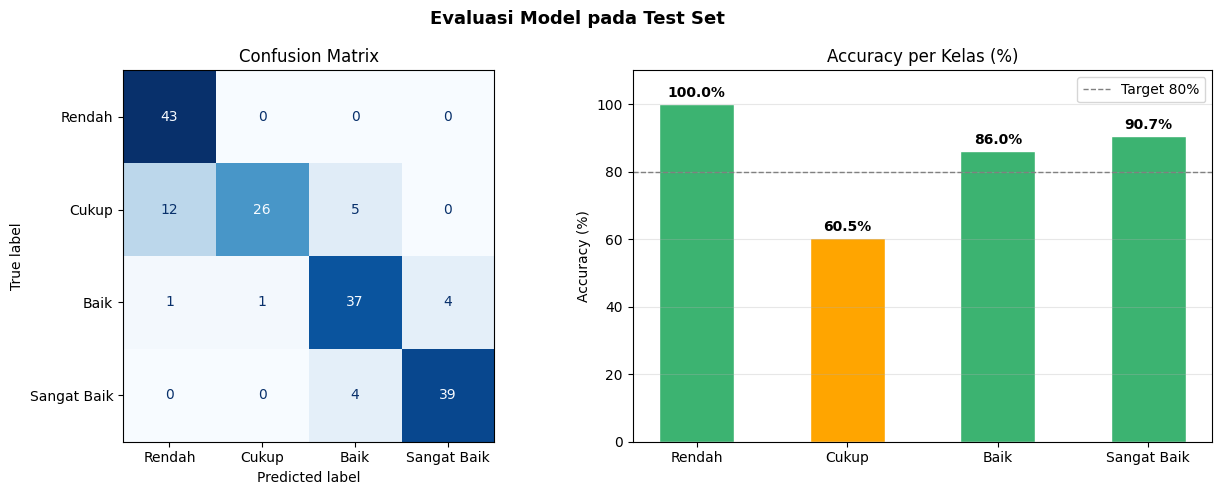

In [13]:
y_pred_prob = model.predict(X_test_sc, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
label_names = [LABEL_KELAS[i] for i in range(4)]

print("=" * 55)
print("EVALUASI MODEL - TEST SET")
print("=" * 55)
print()
print(classification_report(y_test, y_pred, target_names=label_names, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluasi Model pada Test Set', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Per-kelas accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
bar_colors    = ['tomato' if v < 60 else 'orange' if v < 80 else 'mediumseagreen' for v in per_class_acc]
axes[1].bar(label_names, per_class_acc, color=bar_colors, edgecolor='white', width=0.5)
axes[1].axhline(80, color='gray', linestyle='--', linewidth=1, label='Target 80%')
axes[1].set_title('Accuracy per Kelas (%)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
for i, v in enumerate(per_class_acc):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_03_evaluasi.png', dpi=120, bbox_inches='tight')
plt.show()

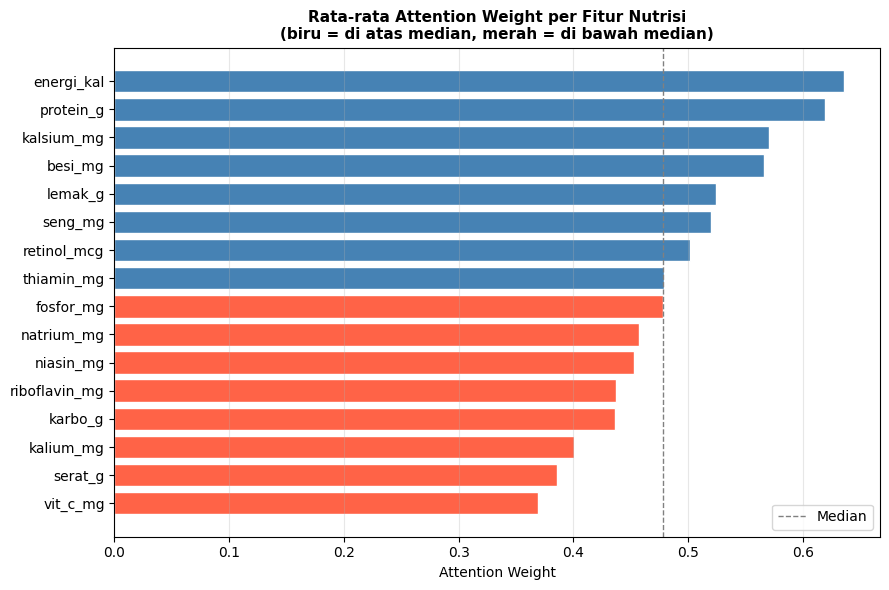

Top 5 nutrisi paling diperhatikan model:
     fitur  attention
   lemak_g   0.524313
   besi_mg   0.566375
kalsium_mg   0.570365
 protein_g   0.619583
energi_kal   0.635352


In [14]:
attention_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer('nutrition_attention').output,
    name    = 'attention_extractor'
)

_, attn_weights = attention_extractor.predict(X_test_sc, verbose=0)
mean_attn = attn_weights.mean(axis=0)

attn_df = pd.DataFrame({'fitur': FITUR_NUTRISI, 'attention': mean_attn})
attn_df = attn_df.sort_values('attention', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_a = ['tomato' if v < attn_df['attention'].median() else 'steelblue' for v in attn_df['attention']]
ax.barh(attn_df['fitur'], attn_df['attention'], color=colors_a, edgecolor='white')
ax.axvline(attn_df['attention'].median(), color='gray', linestyle='--', linewidth=1, label='Median')
ax.set_title('Rata-rata Attention Weight per Fitur Nutrisi\n(biru = di atas median, merah = di bawah median)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Attention Weight')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_04_attention.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 nutrisi paling diperhatikan model:")
print(attn_df.tail(5)[['fitur', 'attention']].to_string(index=False))

In [15]:
import json

MODEL_PATH  = 'smart_nutrition_tracker.keras'
SCALER_PATH = 'scaler_params.json'

# Simpan model
model.save(MODEL_PATH)
print(f"Model disimpan: {MODEL_PATH}")

# Simpan parameter scaler dan metadata
scaler_meta = {
    'mean'          : scaler.mean_.tolist(),
    'std'           : scaler.scale_.tolist(),
    'features'      : FITUR_NUTRISI,
    'label_map'     : {str(k): v for k, v in LABEL_KELAS.items()},
    'quartiles'     : {'q25': float(q25), 'q50': float(q50), 'q75': float(q75)}
}
with open(SCALER_PATH, 'w') as f:
    json.dump(scaler_meta, f, indent=2)
print(f"Scaler params disimpan: {SCALER_PATH}")

# Verifikasi load
model_verify = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'NutritionAttentionLayer': NutritionAttentionLayer,
        'FocalLoss': FocalLoss
    }
)
diff = np.max(np.abs(
    model.predict(X_test_sc[:5], verbose=0) -
    model_verify.predict(X_test_sc[:5], verbose=0)
))
print(f"Verifikasi load model: max diff = {diff:.2e} ({'LULUS' if diff < 1e-5 else 'GAGAL'})")

Model disimpan: smart_nutrition_tracker.keras
Scaler params disimpan: scaler_params.json
Verifikasi load model: max diff = 0.00e+00 (LULUS)


In [16]:
class NutritionInferenceEngine:
    """
    Engine inference untuk Smart Nutrition Tracker.

    Menyediakan antarmuka bersih untuk prediksi kelas gizi makanan baru
    tanpa perlu mengurus preprocessing secara manual.

    Contoh penggunaan:
        engine = NutritionInferenceEngine('smart_nutrition_tracker.keras',
                                          'scaler_params.json')
        result = engine.predict({'energi_kal': 154, 'protein_g': 12.4, ...})
    """

    def __init__(self, model_path: str, scaler_path: str):
        with open(scaler_path) as f:
            meta = json.load(f)

        self.model = keras.models.load_model(
            model_path,
            custom_objects={
                'NutritionAttentionLayer': NutritionAttentionLayer,
                'FocalLoss': FocalLoss
            }
        )
        self.mean      = np.array(meta['mean'],     dtype=np.float32)
        self.std       = np.array(meta['std'],      dtype=np.float32)
        self.features  = meta['features']
        self.label_map = {int(k): v for k, v in meta['label_map'].items()}
        print(f"Model loaded: {model_path}")

    def _preprocess(self, data: dict) -> np.ndarray:
        x = np.array([data.get(f, 0.0) for f in self.features], dtype=np.float32)
        return ((x - self.mean) / (self.std + 1e-8)).reshape(1, -1)

    def predict(self, data: dict) -> dict:
        """
        Prediksi kelas gizi untuk satu bahan makanan (per 100g).

        Parameter:
            data : dict {nama_fitur: nilai_nutrisi}

        Return:
            dict berisi kelas, label, probabilitas per kelas, dan rekomendasi
        """
        x_sc      = self._preprocess(data)
        probs     = self.model.predict(x_sc, verbose=0)[0]
        kelas     = int(np.argmax(probs))
        label     = self.label_map[kelas]

        rekomendasi_map = {
            0: 'Tidak dianjurkan sebagai makanan utama anak usia dini.',
            1: 'Dapat digunakan, kombinasikan dengan sumber nutrisi lebih kaya.',
            2: 'Baik untuk menu harian anak. Variasikan dengan sumber nutrisi lain.',
            3: 'Sangat direkomendasikan untuk menu anak usia 0-6 tahun.'
        }

        return {
            'kelas'        : kelas,
            'label'        : label,
            'probabilitas' : {self.label_map[i]: round(float(p), 4) for i, p in enumerate(probs)},
            'confidence'   : round(float(probs[kelas]), 4),
            'rekomendasi'  : rekomendasi_map[kelas]
        }

    def predict_batch(self, df_input: pd.DataFrame) -> pd.DataFrame:
        """
        Prediksi batch untuk DataFrame berisi banyak bahan makanan.
        """
        X = df_input[self.features].fillna(0).values.astype(np.float32)
        X_sc  = (X - self.mean) / (self.std + 1e-8)
        probs = self.model.predict(X_sc, verbose=0)
        kelas = np.argmax(probs, axis=1)

        result = df_input.copy()
        result['pred_kelas']      = kelas
        result['pred_label']      = [self.label_map[k] for k in kelas]
        result['pred_confidence'] = probs.max(axis=1).round(4)
        return result


# Demo
engine = NutritionInferenceEngine('smart_nutrition_tracker.keras', 'scaler_params.json')
print()

telur_ayam = {
    'energi_kal': 154, 'protein_g': 12.4, 'lemak_g': 10.8,
    'karbo_g': 0.7,    'serat_g': 0.0,    'kalsium_mg': 54,
    'fosfor_mg': 180,  'besi_mg': 2.7,    'natrium_mg': 122,
    'kalium_mg': 134,  'seng_mg': 1.1,    'retinol_mcg': 140,
    'thiamin_mg': 0.12,'riboflavin_mg': 0.35, 'niasin_mg': 0.1,
    'vit_c_mg': 0.0
}

hasil = engine.predict(telur_ayam)
print("Prediksi - Telur Ayam (per 100g)")
print("-" * 40)
for k, v in hasil.items():
    print(f"  {k:<15}: {v}")

Model loaded: smart_nutrition_tracker.keras

Prediksi - Telur Ayam (per 100g)
----------------------------------------
  kelas          : 1
  label          : Cukup
  probabilitas   : {'Rendah': 0.0078, 'Cukup': 0.5586, 'Baik': 0.3373, 'Sangat Baik': 0.0962}
  confidence     : 0.5586
  rekomendasi    : Dapat digunakan, kombinasikan dengan sumber nutrisi lebih kaya.


In [17]:
df_pred = engine.predict_batch(df)

print("Rekomendasi Top 5 Makanan per Kelas Gizi")
print("=" * 60)

for kls in range(3, -1, -1):
    subset = df_pred[df_pred['pred_kelas'] == kls].nlargest(5, 'pred_confidence')
    print(f"\nKelas {kls} - {LABEL_KELAS[kls]} (top 5 confidence tertinggi):")
    print("-" * 55)
    tampil = subset[['nama', 'kategori', 'energi_kal', 'protein_g',
                      'pred_label', 'pred_confidence']].reset_index(drop=True)
    tampil.index += 1
    print(tampil.to_string())

print()
print("Distribusi prediksi seluruh dataset:")
for kls, nama in LABEL_KELAS.items():
    n = (df_pred['pred_kelas'] == kls).sum()
    print(f"  Kelas {kls} ({nama:<12}): {n:>4} ({n/len(df)*100:.1f}%)")

Rekomendasi Top 5 Makanan per Kelas Gizi

Kelas 3 - Sangat Baik (top 5 confidence tertinggi):
-------------------------------------------------------
                                     nama               kategori  energi_kal  protein_g   pred_label  pred_confidence
1  Koro andong, kering (Jack bean, dried)        Kacang-Kacangan       356.0       20.5  Sangat Baik           0.8614
2                Bekicot, dendeng, mentah  Ikan/Kerang/Udang dll       441.0       48.7  Sangat Baik           0.8610
3                    Bungkil kacang tanah        Kacang-Kacangan       336.0       37.4  Sangat Baik           0.8244
4                            Kembang tahu        Kacang-Kacangan       380.0       48.9  Sangat Baik           0.8122
5                    Udang kering, mentah  Ikan/Kerang/Udang dll       278.0       62.6  Sangat Baik           0.8120

Kelas 2 - Baik (top 5 confidence tertinggi):
-------------------------------------------------------
                                        